# Hanks Lab — Raw Doric Fiber Photometry Demo

This notebook demonstrates how to read and visualize the raw lock-in fiber photometry
data stored in an NWB file produced by `hanks-lab-to-nwb`.

The NWB file contains dLight 3.8 dopamine signals acquired simultaneously from up to
four brain regions (NAc, DMS, DLS, PL/TS) using a Doric FP Console.  Each region is
measured at two excitation wavelengths:
- **~415/420 nm** — isosbestic control (motion/bleaching artefact, dopamine-insensitive)
- **490 nm** — dopamine-sensitive dLight signal

Lock-in demodulation is performed on-board by the Doric system before writing to disk.

---

In [1]:
from pathlib import Path

# ── Point this at an NWB file produced by convert_session.py ─────────────────
NWB_PATH = Path("../../../nwb_output/sub-400_ses-119974.nwb")  # Bandit example session

In [2]:
import warnings

import matplotlib.pyplot as plt
import ndx_fiber_photometry  # noqa: F401 — registers extension
import ndx_ophys_devices  # noqa: F401 — registers extension
import numpy as np
from pynwb import NWBHDF5IO

warnings.filterwarnings("ignore", category=UserWarning)

## 1. Open the NWB file and inspect high-level metadata

In [3]:
io = NWBHDF5IO(NWB_PATH, "r", load_namespaces=True)
nwb = io.read()

print("Session ID     :", nwb.session_id)
print("Session start  :", nwb.session_start_time)
print("Subject        :", nwb.subject.subject_id)
print("Species        :", nwb.subject.species)
print("Institution    :", nwb.institution)
print("Lab            :", nwb.lab)
print()
print("Session description:")
print(nwb.session_description)

Session ID     : 119974
Session start  : 2025-10-20 11:47:53-07:00
Subject        : 400
Species        : Rattus norvegicus
Institution    : University of California, Davis
Lab            : Hanks

Session description:
This session contains fiber photometry and behavioral data from a rat performing a two-arm bandit task (ClassicRLTasks). On each trial, the rat initiates at the center port and chooses either the left or right reward port. Reward probabilities are fixed within a block and switch across blocks, requiring the animal to track reward history and update port preferences. Behavioral events are controlled and recorded by Bpod. Fluorescence signals are acquired simultaneously from up to four brain regions using a Doric system with dLight 3.8 (dopamine indicator) at isosbestic and ligand excitation wavelengths.



## 2. Session start time and first fiber photometry timestamp

`session_start_time` is the absolute wall-clock time when the Doric recording began
(read from the `.doric` file's `Created` attribute).  All FP timestamps are offsets
in seconds from this reference — so `t = 0 s` corresponds to `session_start_time` and
the wall-clock time of any sample is `session_start_time + t`.

In [4]:
import datetime

session_start = nwb.session_start_time
print(f"session_start_time : {session_start}")
print()

# Grab the first FP series directly from acquisition (fp_series dict defined later)
fp_ref = next(
    obj for name, obj in nwb.acquisition.items()
    if "FiberPhotometryResponseSeries" in name
)
first_ts = float(
    fp_ref.timestamps[0] if fp_ref.timestamps is not None
    else (fp_ref.starting_time or 0.0)
)
last_ts = float(
    fp_ref.timestamps[-1] if fp_ref.timestamps is not None
    else (fp_ref.starting_time or 0.0) + fp_ref.data.shape[0] / fp_ref.rate
)
n = fp_ref.data.shape[0]

first_wall = session_start + datetime.timedelta(seconds=first_ts)
last_wall  = session_start + datetime.timedelta(seconds=last_ts)

print(f"First FP timestamp : {first_ts:.4f} s  →  wall clock: {first_wall}")
print(f"Last  FP timestamp : {last_ts:.4f} s  →  wall clock: {last_wall}")
print(f"Total samples      : {n:,}  ({last_ts - first_ts:.1f} s duration)")

session_start_time : 2025-10-20 11:47:53-07:00

First FP timestamp : 0.0831 s  →  wall clock: 2025-10-20 11:47:53.083083-07:00
Last  FP timestamp : 4427.6547 s  →  wall clock: 2025-10-20 13:01:40.654671-07:00
Total samples      : 26,672,119  (4427.6 s duration)


## 3. Fiber photometry hardware configuration

In [5]:
fp_meta = nwb.lab_meta_data["fiber_photometry"]
fp_table = fp_meta.fiber_photometry_table

print("FiberPhotometryTable —", fp_table.description)
print()
fp_df = fp_table.to_dataframe()
# Simplify device columns to names only
for col in ["optical_fiber", "excitation_source", "photodetector", "indicator"]:
    if col in fp_df.columns:
        fp_df[col] = fp_df[col].apply(
            lambda x: x.name if hasattr(x, "name") else str(x)
        )
display_cols = ["location", "excitation_wavelength_in_nm", "emission_wavelength_in_nm",
                "optical_fiber", "excitation_source", "photodetector"]
print(fp_df[[c for c in display_cols if c in fp_df.columns]].to_string())

FiberPhotometryTable — Metadata for all fiber photometry recording sites and excitation wavelengths in this session.

   location  excitation_wavelength_in_nm  emission_wavelength_in_nm      optical_fiber             excitation_source       photodetector
id                                                                                                                                      
0       NAc                        420.0                      530.0  optical_fiber_NAc  excitation_source_isosbestic  PhotodetectorAIN01
1        PL                        420.0                      530.0   optical_fiber_PL  excitation_source_isosbestic  PhotodetectorAIN02
2       NAc                        490.0                      530.0  optical_fiber_NAc      excitation_source_signal  PhotodetectorAIN01
3        PL                        490.0                      530.0   optical_fiber_PL      excitation_source_signal  PhotodetectorAIN02
4       DLS                        415.0                    

In [6]:
print("Optical fibers and implant coordinates:")
for name, dev in sorted(nwb.devices.items()):
    if not name.startswith("optical_fiber_"):
        continue
    ins = getattr(dev, "fiber_insertion", None)
    if ins is not None:
        ap   = getattr(ins, "insertion_position_ap_in_mm", "?")
        ml   = getattr(ins, "insertion_position_ml_in_mm", "?")
        dv   = getattr(ins, "insertion_position_dv_in_mm", "?")
        hemi = getattr(ins, "hemisphere", "?")
        print(f"  {name}: AP={ap:+.2f}, ML={ml:+.2f}, DV={dv:.2f} mm  [{hemi}]")
    else:
        print(f"  {name}: no insertion coordinates")

print()
print("Excitation sources:")
for name, dev in sorted(nwb.devices.items()):
    if not name.startswith("excitation_source"):
        continue
    wl_range = getattr(getattr(dev, "model", None), "wavelength_range_in_nm", None)
    wl_str = f"  [{wl_range[0]:.1f}–{wl_range[-1]:.1f} nm]" if wl_range is not None else ""
    print(f"  {name}: {dev.description[:80].rstrip()}{wl_str}")

print()
print("Photodetectors:")
for name, dev in sorted(nwb.devices.items()):
    if not name.startswith("Photodetector"):
        continue
    model = getattr(dev, "model", None)
    det_type   = getattr(model, "detector_type", "?")
    gain       = getattr(model, "gain", "?")
    gain_unit  = getattr(model, "gain_unit", "")
    wl_range   = getattr(model, "wavelength_range_in_nm", None)
    wl_str = f"{wl_range[0]:.0f}–{wl_range[-1]:.0f} nm" if wl_range is not None else "?"
    print(f"  {name}: type={det_type}, gain={gain} {gain_unit}, sensitivity={wl_str}")

print()
print("Band optical filters:")
for name, dev in sorted(nwb.devices.items()):
    if not (name.startswith("emission_filter") or name.startswith("excitation_filter")):
        continue
    if "model" in name:  # skip model objects, show instances only
        continue
    model  = getattr(dev, "model", None)
    center = getattr(model, "center_wavelength_in_nm", "?")
    bw     = getattr(model, "bandwidth_in_nm", "?")
    ftype  = getattr(model, "filter_type", "?")
    print(f"  {name}: {ftype}, center={center} nm, BW={bw} nm")

print()
print("Indicator:")
for ind in fp_meta.fiber_photometry_indicators.indicators.values():
    print(f"  {ind.name} — label: {ind.label}, manufacturer: {ind.manufacturer}")

Optical fibers and implant coordinates:
  optical_fiber_DLS: AP=+0.60, ML=+3.80, DV=-3.80 mm  [left]
  optical_fiber_DMS: AP=+1.10, ML=-2.10, DV=-3.60 mm  [right]
  optical_fiber_NAc: AP=+1.60, ML=+1.60, DV=-7.20 mm  [left]
  optical_fiber_PL: AP=+3.00, ML=-0.60, DV=-3.00 mm  [right]

Excitation sources:
  excitation_source_isosbestic: Doric Connecterized 415 nm isosbestic LED on the FP Console. AOUT01 (420-435 nm  [408.5–421.5 nm]
  excitation_source_signal: Doric Connecterized 490 nm dopamine signal LED on the FP Console. AOUT02 (470-49  [477.0–503.0 nm]

Photodetectors:
  PhotodetectorAIN01: type=PMT, gain=7.6 V/nW, sensitivity=350–1000 nm
  PhotodetectorAIN02: type=PMT, gain=7.6 V/nW, sensitivity=350–1000 nm
  PhotodetectorAIN03: type=PMT, gain=7.6 V/nW, sensitivity=350–1000 nm
  PhotodetectorAIN04: type=PMT, gain=7.6 V/nW, sensitivity=350–1000 nm

Band optical filters:
  emission_filter: Bandpass, center=525.0 nm, BW=50.0 nm
  excitation_filter_isosbestic_DLS: Bandpass, center=415

## 4. List FiberPhotometryResponseSeries in the file

In [7]:
fp_series = {
    name: obj
    for name, obj in nwb.acquisition.items()
    if "FiberPhotometryResponseSeries" in name
}

print(f"Found {len(fp_series)} FiberPhotometryResponseSeries:")
for name, series in sorted(fp_series.items()):
    n_samples = series.data.shape[0]
    ts_start = series.timestamps[0] if series.timestamps is not None else series.starting_time
    ts_end = series.timestamps[-1] if series.timestamps is not None else (
        series.starting_time + n_samples / series.rate
    )
    duration = ts_end - ts_start
    print(f"  {name}: {n_samples:,} samples, {duration:.1f} s, unit={series.unit}")

Found 8 FiberPhotometryResponseSeries:
  FiberPhotometryResponseSeriesIsosbesticControlDLS: 26,672,119 samples, 4427.6 s, unit=V
  FiberPhotometryResponseSeriesIsosbesticControlDMS: 26,672,119 samples, 4427.6 s, unit=V
  FiberPhotometryResponseSeriesIsosbesticControlNAc: 26,672,119 samples, 4427.6 s, unit=V
  FiberPhotometryResponseSeriesIsosbesticControlPL: 26,672,119 samples, 4427.6 s, unit=V
  FiberPhotometryResponseSeriesRawSignalDLS: 26,672,119 samples, 4427.6 s, unit=V
  FiberPhotometryResponseSeriesRawSignalDMS: 26,672,119 samples, 4427.6 s, unit=V
  FiberPhotometryResponseSeriesRawSignalNAc: 26,672,119 samples, 4427.6 s, unit=V
  FiberPhotometryResponseSeriesRawSignalPL: 26,672,119 samples, 4427.6 s, unit=V


## 5. Plot raw fluorescence — all regions, both wavelengths

Each panel shows one brain region.  Grey trace = isosbestic control (415/420 nm).  
Coloured trace = dopamine-sensitive signal (490 nm).

Regions: ['DLS', 'DMS', 'NAc', 'PL']


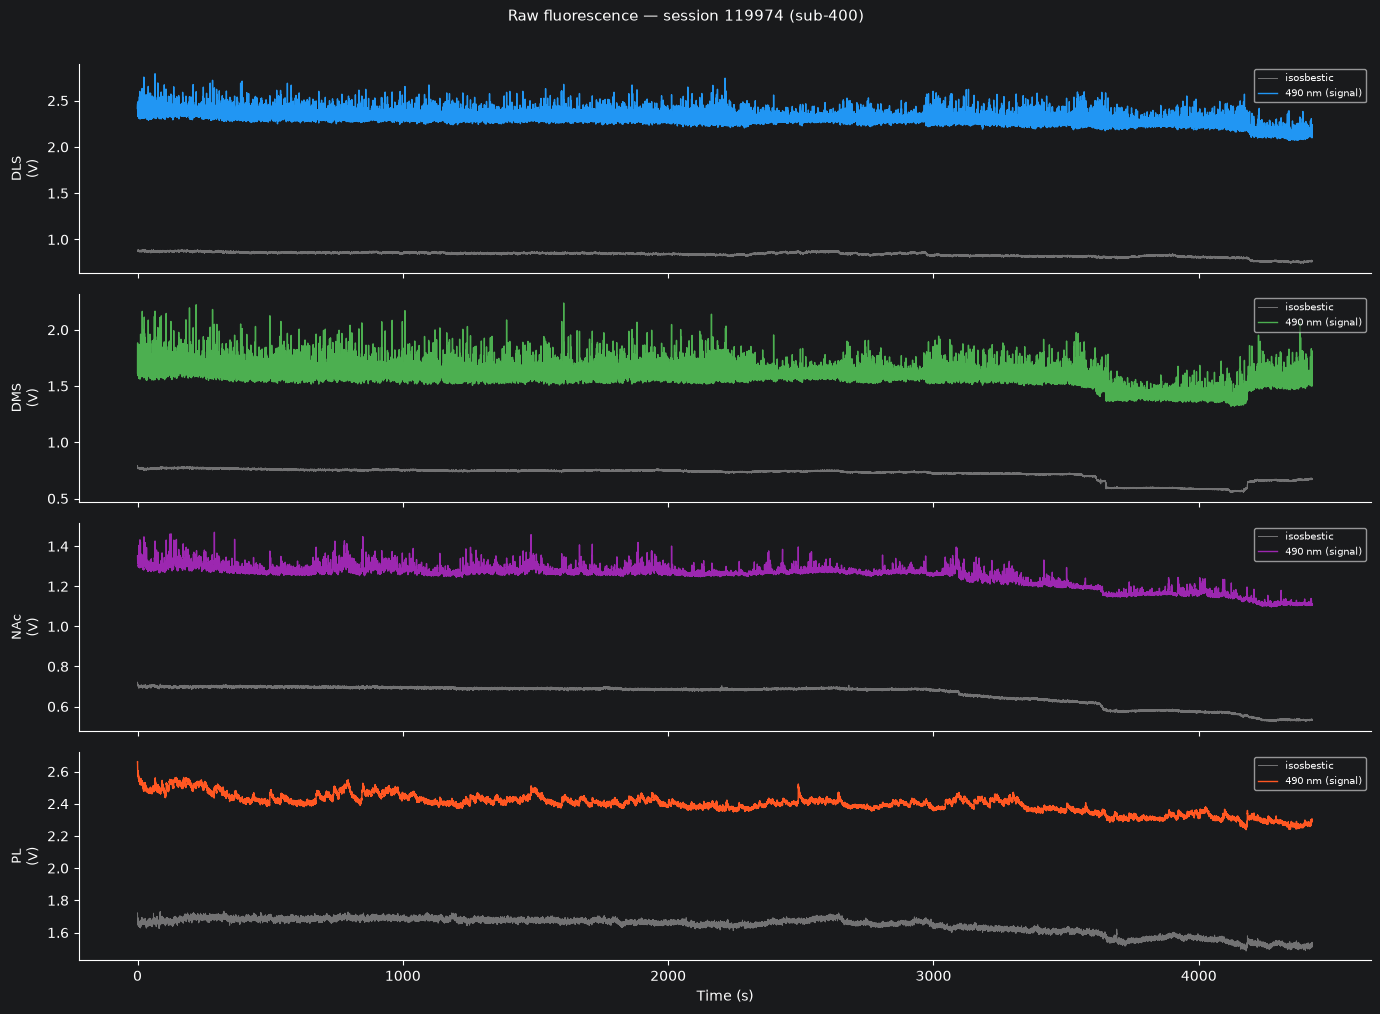

In [8]:
def series_timestamps(series, step=1):
    """Return timestamps for a series stored as explicit array or rate+starting_time."""
    n = series.data.shape[0]
    if series.timestamps is not None:
        return series.timestamps[::step]
    start = series.starting_time if series.starting_time is not None else 0.0
    return start + np.arange(0, n, step) / series.rate

# Extract unique regions from RawSignal series names.
# Name format: FiberPhotometryResponseSeriesRawSignal{region}
_RAW_PREFIX = "FiberPhotometryResponseSeriesRawSignal"
regions = sorted({
    name.removeprefix(_RAW_PREFIX)
    for name in fp_series
    if name.startswith(_RAW_PREFIX)
})
print("Regions:", regions)

SIGNAL_COLOR = {"DLS": "#2196F3", "DMS": "#4CAF50", "NAc": "#9C27B0",
                "PL": "#FF5722", "TS": "#FF9800"}

fig, axes = plt.subplots(len(regions), 1, figsize=(14, 2.5 * len(regions)), sharex=True)
if len(regions) == 1:
    axes = [axes]

for ax, region in zip(axes, regions):
    color = SIGNAL_COLOR.get(region, "steelblue")

    sig_series = fp_series.get(f"FiberPhotometryResponseSeriesRawSignal{region}")
    iso_series = fp_series.get(f"FiberPhotometryResponseSeriesIsosbesticControl{region}")

    # Downsample for display: every 30th sample keeps the plot responsive
    step = 30
    for series, label, lcolor, lw, alpha in [
        (iso_series, "isosbestic", "#999", 0.7, 0.7),
        (sig_series, "490 nm (signal)", color, 1.0, 1.0),
    ]:
        if series is None:
            continue
        ts = series_timestamps(series, step=step)
        data = series.data[::step]
        ax.plot(ts, data, color=lcolor, lw=lw, alpha=alpha,
                label=label, rasterized=True)

    ax.set_ylabel(f"{region}\n(V)", fontsize=9)
    ax.legend(loc="upper right", fontsize=7, framealpha=0.7)
    ax.spines[["top", "right"]].set_visible(False)

axes[-1].set_xlabel("Time (s)")
fig.suptitle(
    f"Raw fluorescence — session {nwb.session_id} (sub-{nwb.subject.subject_id})",
    y=1.01, fontsize=11,
)
plt.tight_layout()
plt.show()

## 6. Zoom into first 60 seconds — lock-in modulation visible

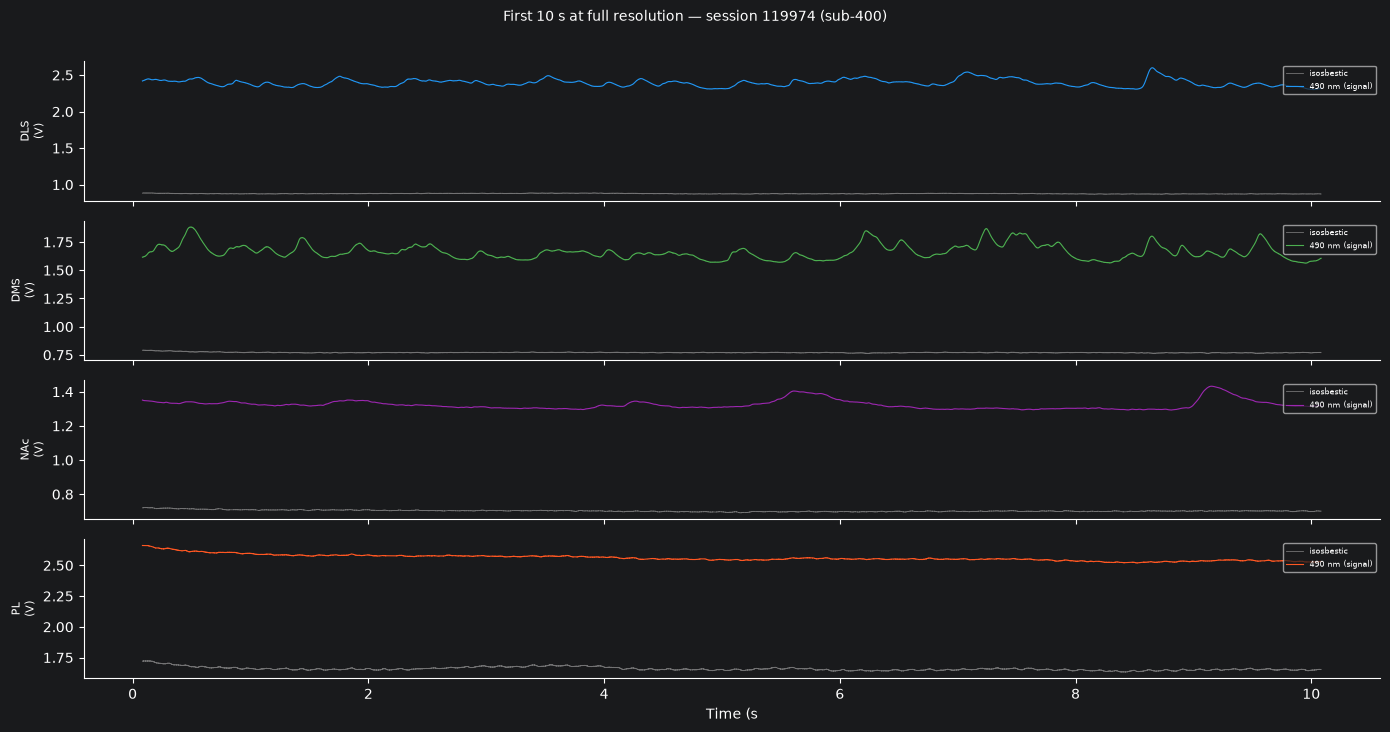

In [9]:
fig, axes = plt.subplots(len(regions), 1, figsize=(14, 1.8 * len(regions)), sharex=True)
if len(regions) == 1:
    axes = [axes]

for ax, region in zip(axes, regions):
    color = SIGNAL_COLOR.get(region, "steelblue")

    sig_series = fp_series.get(f"FiberPhotometryResponseSeriesRawSignal{region}")
    iso_series = fp_series.get(f"FiberPhotometryResponseSeriesIsosbesticControl{region}")

    for series, label, lcolor, lw, alpha in [
        (iso_series, "isosbestic", "#999", 0.6, 0.7),
        (sig_series, "490 nm (signal)", color, 0.8, 1.0),
    ]:
        if series is None:
            continue
        ts = series_timestamps(series)
        t_start = ts[0]
        mask = ts <= (t_start + 10)
        ax.plot(ts[mask], series.data[mask], color=lcolor, lw=lw, alpha=alpha,
                label=label, rasterized=True)

    ax.set_ylabel(f"{region}\n(V)", fontsize=8)
    ax.legend(loc="upper right", fontsize=6, framealpha=0.7)
    ax.spines[["top", "right"]].set_visible(False)

axes[-1].set_xlabel("Time (s")
fig.suptitle(
    f"First 10 s at full resolution — session {nwb.session_id} (sub-{nwb.subject.subject_id})",
    y=1.01, fontsize=10,
)
plt.tight_layout()
plt.show()

In [10]:
io.close()